# day 10 | 250919 F

## hitherto
We started integration but didn't make it very far. So let's get back into it.

## herein
Integration is essentially addition and so there are fewer problems with dividing by a small number like we had with differentiation. But we still need to be careful about errors like round off. Also similar to differentiation, there is a forward and backward way to integrate, and neither of these are accurate enough to be useful, but there is something in between, in the case of integration that is the trapezoidal rule. And like with differentiation there will be a slightly more complicated method, but also even better than trapezoidal and that is Simpson's rule. 

We will start with Riemann's definition of the integral:

$$\int^b_a f(x) \mathrm{d}x = \lim_{N\rightarrow \infty} \sum_{n=0}^{N-1} f(x_n) h = \lim_{N\rightarrow \infty} \sum_{n=1}^{N} f(x_n) h$$

This simply tells us that these right and left sums are the same when the divisions go to infinity. But this rectangular rule, once we can't go to infinity causes problems. A trapezoidal rule, which in a way is the average of both:

$$\int^b_a f(x) \mathrm{d}x \approx \sum_{n=0}^{N-1} \frac{f(x_{n+1}) +f(x_n)}{2}h$$
This has the effect after factoring out h/2 and expanding the sum of: 
$$\int^b_a f(x) \mathrm{d}x \approx \frac{h}{2}[f(x_0) + 2f(x_1) + 2f(x_3)+...+ 2f(x_{N-1}) + f(x_{N})]$$

Which can be rewritten as
$$\int^b_a f(x) \mathrm{d}x \approx \frac{h}{2}[f(a) + f(b)] + \sum_{n=1}^{N-1}f(x_n)h$$

And now we can calculate this sum much faster. Implementing this can have some "gotchas", so we have to be careful about how we go about pulling this calculation off. 

Do exercise 5.1 to practice this. But also go back and work on exercise 3.8 as a call back to that chapter on graphing. This is a classic example of a problem that *seems* very difficult, but actually the author walks you through nicely.

## hence

One thing I wish I had said, was how the trapezoid rule was like an average of the left and right Riemann Sum's. I think that would have made the logic of the sum much clearer. 

Also I didn't get to Simpson's rule, but it is a modification where we are essentially using parabola's rather than trapezoids to model the curve. 


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [85]:
x0 = np.linspace(0, 2, 1000)
x = np.linspace(0, 2, 5)

In [86]:
y0 = x0**4 - 2*x0 + 1
y = x**4 - 2*x + 1

In [87]:
dx = x[1]-x[0]

In [88]:
ydx = y * dx

In [89]:
ydx[:-1].sum()

2.0625

<BarContainer object of 4 artists>

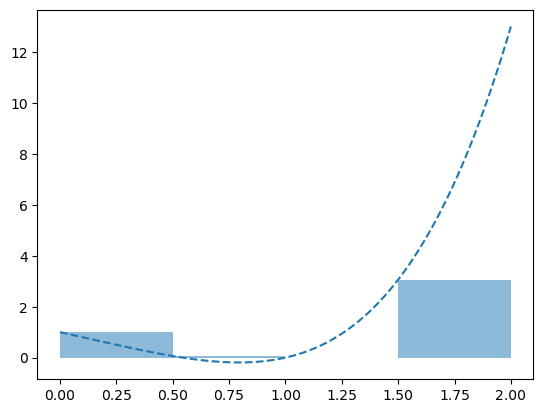

In [90]:
fig0, ax0 = plt.subplots()

ax0.plot(x0, y0, '--')
ax0.bar(x[:-1], y[:-1], alpha=0.5, align='edge', width=dx)

In [91]:
def integrate(func, a, b, steps):
    dx = (b-a)/steps
    x = np.linspace(a, b, steps+1)
    y = func(x)
    s = dx/2*(func(a)+func(b))
    s = s + np.sum(y[1:steps]*dx)
    return(s)

In [92]:
def f(x):
    return(x**4 - 2*x + 1)

In [93]:
integrate(f, 0, 2, 100)

4.401066656

# after class

I played around with chatgpt to get this plot which shows how the trapezoidal method is working. Don't worry about reproducing this, but I wanted to show you how it works.

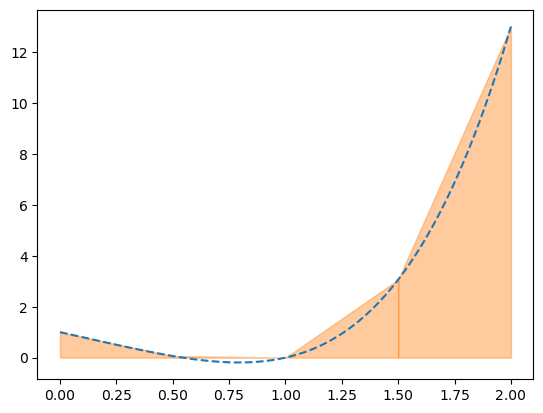

In [95]:
fig1, ax1 = plt.subplots()
ax1.plot(x0, y0, '--')

for i in range(len(x)-1):
    xs = [x[i], x[i+1]]
    ys = [y[i], y[i+1]]
    ax1.fill_between(xs, ys, alpha=0.4, color='C1')

And now I have a plot of simpson's rule with the parabolas shading a similar section and you can see how much better this is that even the trapezoid rule.

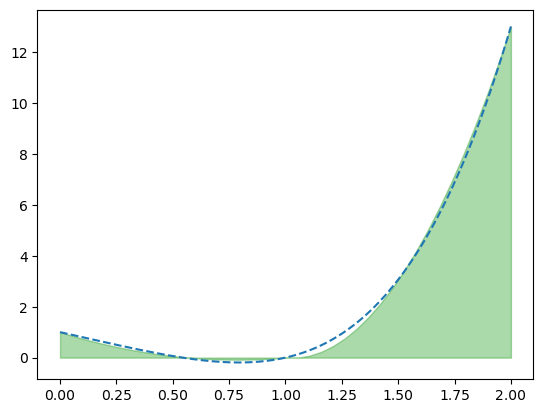

In [96]:
fig2, ax2 = plt.subplots()
ax2.plot(x0, y0, '--')

for i in range(0, len(x)-2, 2):  # step by 2
    xs = np.linspace(x[i], x[i+2], 20)
    coeffs = np.polyfit([x[i], x[i+1], x[i+2]],
                        [y[i], y[i+1], y[i+2]], 2)
    ys = np.polyval(coeffs, xs)
    ax2.fill_between(xs, ys, alpha=0.4, color='C2')